## imports

In [61]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## importing the data

In [62]:
order = pd.read_csv("../BankData/order.csv",delimiter=";")

order

,order_id,account_id,bank_to,account_to,amount,k_symbol
0,29401,1,YZ,87144583,2452.0,SIPO
1,29402,2,ST,89597016,3372.7,UVER
2,29403,2,QR,13943797,7266.0,SIPO
3,29404,3,WX,83084338,1135.0,SIPO
4,29405,3,CD,24485939,327.0,
...,...,...,...,...,...,...
6466,46334,11362,YZ,70641225,4780.0,SIPO
6467,46335,11362,MN,78507822,56.0,
6468,46336,11362,ST,40799850,330.0,POJISTNE
6469,46337,11362,KL,20009470,129.0,


## check for nulls

In [63]:
order.isna().sum()

order_id      0
account_id    0
bank_to       0
account_to    0
amount        0
k_symbol      0
dtype: int64

## K_symbol

In [64]:
order["k_symbol"].value_counts()

k_symbol
SIPO        3502
            1379
UVER         717
POJISTNE     532
LEASING      341
Name: count, dtype: int64

1.1 map to english 

In [65]:
# 1. Strip whitespace
order['k_symbol'] = order['k_symbol'].astype(str).str.strip()

# 2. Map the Czech terms to English
czech_to_english = {
    'SIPO': 'household_utility',
    'UVER': 'loan_payment',
    'POJISTNE': 'insurance_payment',
    'LEASING': 'leasing',
    '': 'other_unknown',
    'nan': 'other_unknown'
}

order['k_symbol'] = order['k_symbol'].map(czech_to_english).fillna('other_unknown')

# 3. Verify the updated counts
pd.DataFrame(order['k_symbol'].value_counts())

,count
k_symbol,
household_utility,3502
other_unknown,1379
loan_payment,717
insurance_payment,532
leasing,341


1.2 make it payment_type

In [66]:
order = order.rename(columns={'k_symbol': 'payment_type'})

order.head()

,order_id,account_id,bank_to,account_to,amount,payment_type
0,29401,1,YZ,87144583,2452.0,household_utility
1,29402,2,ST,89597016,3372.7,loan_payment
2,29403,2,QR,13943797,7266.0,household_utility
3,29404,3,WX,83084338,1135.0,household_utility
4,29405,3,CD,24485939,327.0,other_unknown


## removing the account_to and bank_to 
because they doesnt refer to anything in our datasets

In [67]:
order = order.drop(columns=['account_to', 'bank_to'])

## histplot amount 

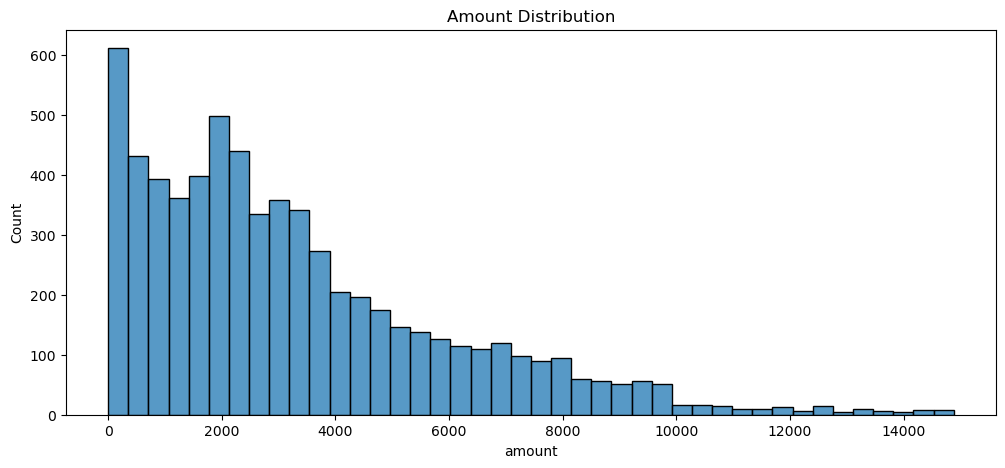

In [68]:
plt.figure(figsize=(12, 5))
sns.histplot(order['amount'])
plt.title("Amount Distribution")
plt.show()

In [69]:
print("payments with 0 money  :" , order[order["amount"] == 0.0 ].shape[0])

payments with 0 money  : 0


In [70]:
print("payments under 50 :" , order[order["amount"] < 50.0 ].shape[0])

payments under 50 : 146


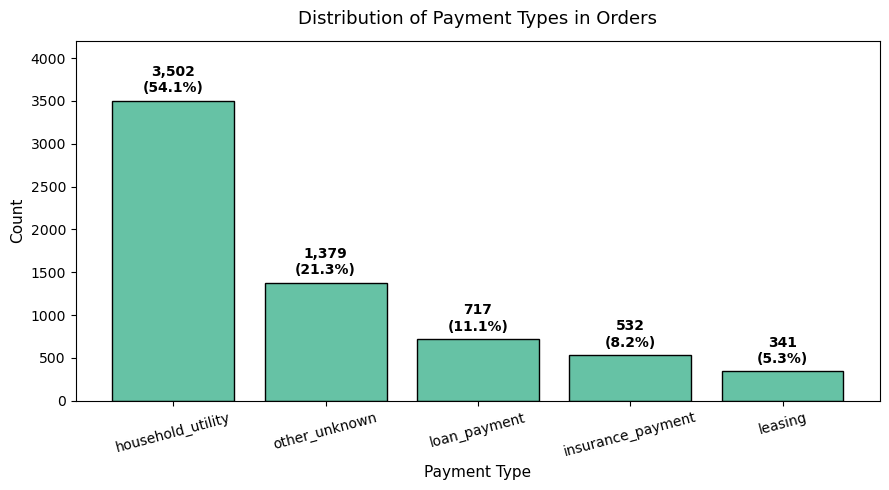

In [71]:
import matplotlib.pyplot as plt

# 1. Calculate counts and percentages
counts = order['payment_type'].value_counts()
percentages = order['payment_type'].value_counts(normalize=True) * 100

# 2. Plot
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(counts.index, counts.values, color='#66c2a5', edgecolor='black')

# 3. Add text labels on top of each bar
for bar, pct in zip(bars, percentages.values):
    height = bar.get_height()
    ax.annotate(
        f"{int(height):,}\n({pct:.1f}%)",
        (bar.get_x() + bar.get_width() / 2.0, height),
        ha='center',
        va='bottom',
        xytext=(0, 4),
        textcoords='offset points',
        fontweight='bold'
    )

ax.set_title("Distribution of Payment Types in Orders", fontsize=13, pad=12)
ax.set_xlabel("Payment Type", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_ylim(0, counts.max() * 1.2)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [72]:
order.head()

,order_id,account_id,amount,payment_type
0,29401,1,2452.0,household_utility
1,29402,2,3372.7,loan_payment
2,29403,2,7266.0,household_utility
3,29404,3,1135.0,household_utility
4,29405,3,327.0,other_unknown


In [73]:
# Statistical overview per payment category
order.groupby('payment_type')['amount'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
payment_type,,,,,,,,
household_utility,3502.0,3987.84,2864.99,1.0,2003.25,3189.5,5529.75,14882.0
insurance_payment,532.0,1291.22,1758.75,1.0,176.00,629.0,1629.50,12504.0
leasing,341.0,2227.35,1181.92,397.0,1278.50,1951.3,3072.10,4975.2
loan_payment,717.0,4233.17,2234.52,304.0,2482.00,3990.8,5902.20,9910.0
other_unknown,1379.0,2017.36,2113.86,1.0,475.00,1339.0,2867.00,12925.0


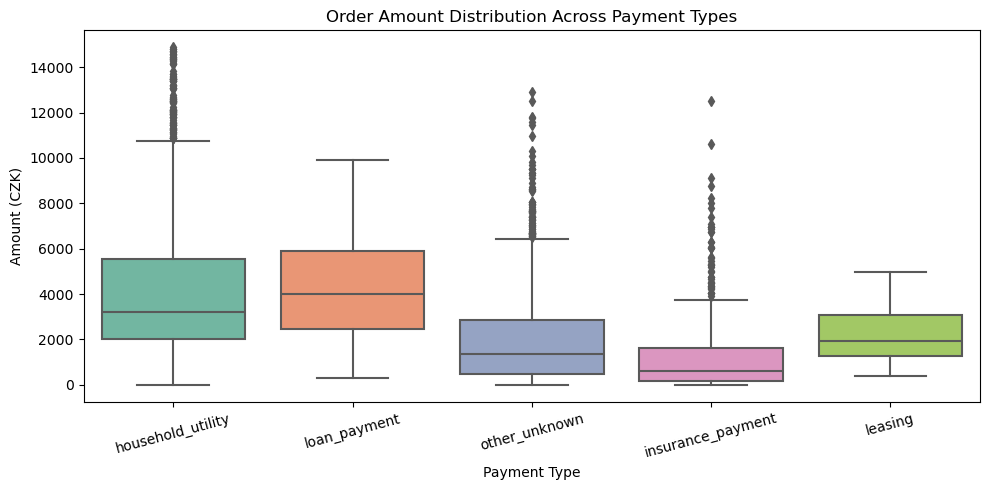

In [74]:
# Boxplot to compare transaction ranges and identify outliers
plt.figure(figsize=(10, 5))
sns.boxplot(data=order, x='payment_type', y='amount', palette='Set2')
plt.title("Order Amount Distribution Across Payment Types")
plt.xlabel("Payment Type")
plt.ylabel("Amount (CZK)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## save clean


In [75]:
order.to_csv("../cleanData/clean_order.csv", sep=";", index=False)